# **Dependencies**

**Importing The Dependencies**

In [165]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# **Data Collection**

In [166]:
# load the clean data from csv to a pandas DataFrame
df = pd.read_csv("../dataset/cleaned data/clean_credit_risk_dataset.csv")

In [167]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,own,5.0,education,b,1000,11.14,0,0.10,n,2
1,25,9600,mortgage,1.0,medical,c,5500,12.87,1,0.57,n,3
2,23,65500,rent,4.0,medical,c,35000,15.23,1,0.53,n,2
3,24,54400,rent,8.0,medical,c,35000,14.27,1,0.55,y,4
4,21,9900,own,2.0,venture,a,2500,7.14,1,0.25,n,2


In [168]:
df['loan_status'].value_counts()

loan_status
0    25321
1     7088
Name: count, dtype: int64

0 -> Paid (Non-Default Value)

1 -> Not Paid (Default Value)

# **Data Splitting**

**Separating Features and Target**

In [169]:
# separate features (X) and target (Y)
X = df.drop('loan_status', axis=1)
Y = df['loan_status']

In [170]:
print(X)

       person_age  person_income person_home_ownership  person_emp_length  \
0              21           9600                   own                5.0   
1              25           9600              mortgage                1.0   
2              23          65500                  rent                4.0   
3              24          54400                  rent                8.0   
4              21           9900                   own                2.0   
...           ...            ...                   ...                ...   
32404          57          53000              mortgage                1.0   
32405          54         120000              mortgage                4.0   
32406          65          76000                  rent                3.0   
32407          56         150000              mortgage                5.0   
32408          66          42000                  rent                2.0   

           loan_intent loan_grade  loan_amnt  loan_int_rate  \
0           

In [171]:
print(Y)

0        0
1        1
2        1
3        1
4        1
        ..
32404    0
32405    0
32406    1
32407    0
32408    0
Name: loan_status, Length: 32409, dtype: int64


**Splitting the data into Training and Test Data**

In [172]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=3)

In [173]:
print(X.shape, X_train.shape, X_test.shape)

(32409, 11) (25927, 11) (6482, 11)


# **Data Preprocessing**

**Label Encoder**

In [174]:
# load the label encoder
label_encoder = LabelEncoder()

In [175]:
# fit and transform training and test data
X_train['cb_person_default_on_file'] = label_encoder.fit_transform(X_train['cb_person_default_on_file'])
X_test['cb_person_default_on_file'] = label_encoder.fit_transform(X_test['cb_person_default_on_file'])

In [176]:
X_train.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
27771,27,42504,rent,2.0,personal,b,7200,10.59,0.17,0,9
5095,25,43500,mortgage,2.0,homeimprovement,a,9000,9.63,0.21,0,4
29263,44,26500,mortgage,5.0,debtconsolidation,a,6200,6.03,0.23,0,16
10103,24,55000,rent,5.0,venture,a,9500,9.63,0.17,0,4
26849,31,120000,mortgage,8.0,education,a,20000,7.49,0.17,0,6


**One-Hot Encoder**

In [177]:
# Define Categories
category_cols = ['person_home_ownership','loan_intent','loan_grade']

# initialize    andfit only on training data
encoder = OneHotEncoder(sparse_output = False, handle_unknown='ignore')
encoder.fit(X_train[category_cols])

# Transform  both 
train_encoded = encoder.transform(X_train[category_cols])
test_encoded = encoder.transform(X_test[category_cols])

# Reverting it to dataframe
train_encoded_df =pd.DataFrame(train_encoded, columns = encoder.get_feature_names_out(category_cols), index = X_train.index)
test_encoded_df =pd.DataFrame(test_encoded, columns = encoder.get_feature_names_out(category_cols), index = X_test.index)

# drop old string columns and the new column with value 0 and 1
X_train_final = pd.concat([X_train.drop(category_cols, axis=1), train_encoded_df], axis=1)
X_test_final = pd.concat([X_test.drop(category_cols, axis=1), test_encoded_df], axis=1)

In [178]:
print(train_encoded_df)
print(test_encoded_df)

       person_home_ownership_mortgage  person_home_ownership_other  \
27771                             0.0                          0.0   
5095                              1.0                          0.0   
29263                             1.0                          0.0   
10103                             0.0                          0.0   
26849                             1.0                          0.0   
...                               ...                          ...   
28928                             0.0                          0.0   
3818                              0.0                          0.0   
24417                             0.0                          0.0   
12925                             0.0                          0.0   
23292                             1.0                          0.0   

       person_home_ownership_own  person_home_ownership_rent  \
27771                        0.0                         1.0   
5095                         0.

**Data Standardization**

In [179]:
# Define Numerical Value
numerical_cols = ['person_age','person_income','person_emp_length','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length']

scaler = StandardScaler()

# fit only on Training Data
scaler.fit(X_train_final[numerical_cols])

# Transform both sets
X_train_final_scale = X_train_final.copy()
X_test_final_scale = X_test_final.copy()

X_train_final_scale[numerical_cols] = scaler.transform(X_train_final[numerical_cols])
X_test_final_scale[numerical_cols] = scaler.transform(X_test_final[numerical_cols])

print("Data is now encoded and scaled. Preview of first 5 rows")
X_train_final_scale.head()

Data is now encoded and scaled. Preview of first 5 rows


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_mortgage,person_home_ownership_other,...,loan_intent_medical,loan_intent_personal,loan_intent_venture,loan_grade_a,loan_grade_b,loan_grade_c,loan_grade_d,loan_grade_e,loan_grade_f,loan_grade_g
27771,-0.115885,-0.435302,-0.692170,-0.375445,-0.135511,0.002317,0,0.787625,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5095,-0.439286,-0.416773,-0.692170,-0.089613,-0.446535,0.379018,0,-0.446660,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
29263,2.633023,-0.733034,0.060236,-0.534240,-1.612876,0.567368,0,2.515626,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
10103,-0.600987,-0.202831,0.060236,-0.010215,-0.446535,0.002317,0,-0.446660,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
26849,0.530917,1.006404,0.812642,1.657138,-1.139860,0.002317,0,0.047054,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


# **Model Selection & Development**

In [180]:
# list of models

models = [LogisticRegression(max_iter = 10000), RandomForestClassifier()]

def compare_models_cross_validation():
    for model in models:
    
        cv_score = cross_val_score(model , X_train_final_scale ,Y_train , cv=5)
        mean_accuracy = (sum(cv_score)/len(cv_score))* 100
        mean_accuracy = round(mean_accuracy, 2)

        print(f"Cross Validation Accuracies for the {model} = {cv_score}")
        print(f'Accuracy Score of the {mean_accuracy} %.')
        print('-' * 150)

        
compare_models_cross_validation()

Cross Validation Accuracies for the LogisticRegression(max_iter=10000) = [0.85576552 0.86887775 0.86075217 0.87020251 0.86711668]
Accuracy Score of the 86.45 %.
------------------------------------------------------------------------------------------------------------------------------------------------------
Cross Validation Accuracies for the RandomForestClassifier() = [0.92846124 0.93578866 0.93134041 0.93211186 0.93539055]
Accuracy Score of the 93.26 %.
------------------------------------------------------------------------------------------------------------------------------------------------------


For this dataset, **Random Forest Classifier** has the highest accuracy value with default hyperparameter values

Now, Comparing the models with different Hyperparameter values using GridSearchCV

In [181]:
# creating a dictionary that contains hyperparameter values for the above mentioned models

model_hyperparameters= {
    'log_reg_hyperparameters': {
        'C' :[1,5,10,20]
        },

    'random_forest_hyperparameters' : {
        'n_estimators' : [10, 20, 50,100],
        'max_depth' : [10,12,15],
        'min_samples_leaf' : [5,10],
        'max_features' : ['sqrt']
    }
}

print(model_hyperparameters)
print(model_hyperparameters.keys())

{'log_reg_hyperparameters': {'C': [1, 5, 10, 20]}, 'random_forest_hyperparameters': {'n_estimators': [10, 20, 50, 100], 'max_depth': [10, 12, 15], 'min_samples_leaf': [5, 10], 'max_features': ['sqrt']}}
dict_keys(['log_reg_hyperparameters', 'random_forest_hyperparameters'])


In [182]:
model_keys = list(model_hyperparameters.keys())
print(model_keys)

type(model_keys)

['log_reg_hyperparameters', 'random_forest_hyperparameters']


list

**Applying GridSearchCV**

In [183]:
def ModelSelection(list_of_models, hyperparameters_dictionary):
    result = []

    i = 0

    for model in list_of_models:
        key = model_keys[i]

        params =hyperparameters_dictionary[key]

        i+=1

        print(model)
        print(params)
        print('-' * 180)

        classifier = GridSearchCV(model, params, cv=5)

        # fitting the processed data to classifier
        classifier.fit(X_train_final_scale, Y_train)

        result.append({
            'model used' : model,
            'highest score' : classifier.best_score_,
            'best hyperparameters' : classifier.best_params_
        })

    result_dataframe = pd.DataFrame(result, columns= ['model used','highest score','best hyperparameters'])

    return result_dataframe

In [184]:
ModelSelection(models, model_hyperparameters)

LogisticRegression(max_iter=10000)
{'C': [1, 5, 10, 20]}
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
RandomForestClassifier()
{'n_estimators': [10, 20, 50, 100], 'max_depth': [10, 12, 15], 'min_samples_leaf': [5, 10], 'max_features': ['sqrt']}
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


,model used,highest score,best hyperparameters
0,LogisticRegression(max_iter=10000),0.864929,{'C': 20}
1,RandomForestClassifier(),0.930613,"{'max_depth': 15, 'max_features': 'sqrt', 'min..."


Random Forest Classifier has the highest accuracy when n_estimators is 100.

**Model Training**

In [185]:
# training the model
model = RandomForestClassifier(n_estimators=100,max_depth=15, max_features='sqrt', min_samples_leaf= 5)
model.fit(X_train_final_scale, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# **Model Evaluation**

**Accuracy Score**

In [186]:
# accuracy on training data
X_train_final_prediction = model.predict(X_train_final_scale)
training_data_accuracy = accuracy_score(Y_train, X_train_final_prediction)
print("Accuracy score of training data: ", round(training_data_accuracy * 100,2))

Accuracy score of training data:  93.74


In [187]:
# accurqacy on test data
X_test_final_prediction = model.predict(X_test_final_scale)
test_data_accuracy = accuracy_score(Y_test, X_test_final_prediction)
print("Accuracy score of test data: ", round(test_data_accuracy * 100,2))

Accuracy score of test data:  93.34


**Initial Attempt:** I first trained the Random Forest with only n_estimators as a hyperparameter The model achieived 99.9 % training accuracy but only 93.5 % test accuracy. The 6% indicates overfitting as Random Forest Classifier model may have memorized specific training instances. To prevent overfitting, I applied regularization using max_depth, max_features and min_samples_leaf to prune the trees and force generalization.

**Final Result:** After updating optimal hyperparameters of GridSearchCV, the model achieved 93.7% training and 93.3% test data accuracy. The overfitting problem is resolved and the model is now stable for real-world data. 


**Confusion Matrix**

In [188]:
cf_matrix = confusion_matrix(Y_test, X_test_final_prediction)
print(cf_matrix)

[[5033   31]
 [ 401 1017]]


In [189]:
tn, fp, fn, tp = cf_matrix.ravel()

print(tn, fp, fn,tp)

5033 31 401 1017


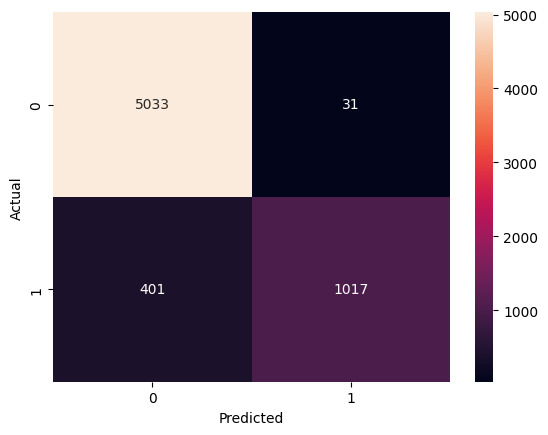

In [190]:
sns.heatmap(cf_matrix, annot=True, fmt='d') # fmt forces the heatmap to show full integer
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Precision, Recall and F1 Score**

In [191]:
def precision_recall_f1_score(true_labels, pred_labels):
    precision_value = precision_score(true_labels, pred_labels)

    recall_value= recall_score(true_labels, pred_labels)

    f1_score_value = f1_score(true_labels, pred_labels)

    print("Precision = ", precision_value)
    print("Recall = ", recall_value)
    print("F1 Score = ", f1_score_value)

In [192]:
# classification matrix for training data
precision_recall_f1_score(Y_train, X_train_final_prediction)

Precision =  0.9884141926140478
Recall =  0.7222222222222222
F1 Score =  0.8346071537756038


In [193]:
# classification matrix for test data
precision_recall_f1_score(Y_test, X_test_final_prediction)

Precision =  0.9704198473282443
Recall =  0.7172073342736248
F1 Score =  0.8248175182481752


The model achieved an F1-Score of around 0.82 with high Precision score of around 0.97. While the Recall score of 0.71 indicates that we missed roughly 29% of defaults, the extremely high  Precision ensures that we are not alienating reliable customers by misclassifying them as high-risk.

**Feature Importance**

In [194]:
# Get the important feature from the trained model
importances = model.feature_importances_

# Match them with column names
feature_names = X_train_final_scale.columns
feature_importance_df = pd.DataFrame({'Features' : feature_names, 'Importance' : importances})

# Sort them from higher to lower
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

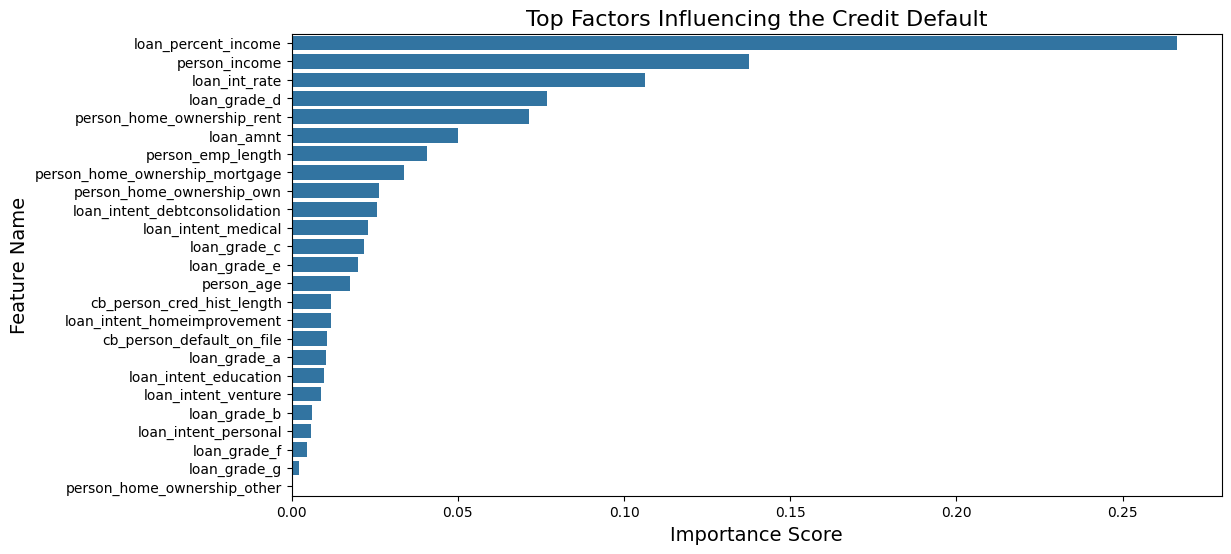

In [195]:
# Plot the results
plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Features', data=feature_importance_df)
plt.title("Top Factors Influencing the Credit Default", fontsize=16)
plt.xlabel("Importance Score", fontsize=14)
plt.ylabel("Feature Name", fontsize=14)
plt.show()

# **Predictive System**

**Making a Predictive System**

In [196]:
# dictionary to store the input data of clients
input_data = {'person_age' :21,
             'person_income' : 9600,
             'person_home_ownership' : 'own',
             'person_emp_length' : 5.0,
             'loan_intent' : 'education',
             'loan_grade' : 'b',
             'loan_amnt' : 1000,
             'loan_int_rate' : 11.14,
             'loan_percent_income' : 0.1,
             'cb_person_default_on_file' : 'n',
             'cb_person_cred_hist_length' : 2}


# convert to pandas DataFrame
input_data_as_dataframe = pd.DataFrame([input_data]) 

# use the saved Label Encoder
input_data_as_dataframe['cb_person_default_on_file'] = label_encoder.transform(input_data_as_dataframe['cb_person_default_on_file'])

# use the saved Standard Scaler
std_data = scaler.transform(input_data_as_dataframe[numerical_cols])
std_num_df = pd.DataFrame(std_data, columns= numerical_cols)

# use the saved One-Hot Encoder
one_encoded_data = encoder.transform(input_data_as_dataframe[category_cols])
one_encoded_df = pd.DataFrame(one_encoded_data, columns= encoder.get_feature_names_out(category_cols))

# Concatenate them together
final_X = pd.concat([std_num_df, one_encoded_df, input_data_as_dataframe[['cb_person_default_on_file']]], axis=1)

# Reindex to match the training column order exactly
final_X = final_X[X_train_final_scale.columns]

prediction = model.predict(final_X)
print(prediction)

if (prediction[0] == 0):
    print('Paid. No loan')

else:
    print('Not Paid. Default')

[0]
Paid. No loan
